# Backtesting & Advanced Analysis

Backtest portfolio performance and conduct sensitivity analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from xgboost import XGBRegressor

# Load data
price_df = pd.read_csv('price_data.csv', index_col=0, parse_dates=True)
returns = pd.read_csv('returns_data.csv', index_col=0, parse_dates=True)
stocks = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "NVDA"]

In [3]:
# Time-series cross-validation backtesting
backtest_data = returns[stocks].copy()
train_window = 252  # 1 year
test_window = 63    # 3 months
total_periods = len(backtest_data)

# Load pre-trained model if available
try:
    model = XGBRegressor()
    model.load_model('xgboost_model.json')
    print("✓ Pre-trained model loaded")
except:
    print("Note: Pre-trained model not found. Will train models during backtesting.")
    model = None

# Storage for results
optimized_returns = []
equal_weight_returns = []
optimized_weights_history = []
dates_history = []

print(f"Total trading days: {total_periods}")
print(f"Train window: {train_window}, Test window: {test_window}")
print(f"Starting backtesting...\n")

✓ Pre-trained model loaded
Total trading days: 1258
Train window: 252, Test window: 63
Starting backtesting...



In [4]:
# Optimization functions
def portfolio_performance(weights, mean_ret, cov_mat, rf_rate=0.02/252):
    portfolio_return = np.sum(mean_ret * weights)
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
    sharpe_ratio = (portfolio_return - rf_rate) / portfolio_std if portfolio_std > 0 else 0
    return portfolio_return, portfolio_std, sharpe_ratio

def neg_sharpe(weights, mean_ret, cov_mat):
    return -portfolio_performance(weights, mean_ret, cov_mat)[2]

constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
bounds = tuple((0, 1) for _ in range(len(stocks)))
init_guess = np.array([1/len(stocks)] * len(stocks))

In [5]:
# Backtesting loop
for test_start in range(train_window, total_periods - test_window, test_window):
    test_end = min(test_start + test_window, total_periods)
    
    train_data = backtest_data.iloc[:test_start].copy()
    test_data = backtest_data.iloc[test_start:test_end].copy()
    
    if len(train_data) < train_window or len(test_data) == 0:
        continue
    
    period_date = backtest_data.index[test_start]
    dates_history.append(period_date)
    
    # Optimize portfolio
    recent_mean_returns = train_data.iloc[-252:].mean()
    result = minimize(neg_sharpe, init_guess,
                     args=(recent_mean_returns, train_data.cov()),
                     method='SLSQP', bounds=bounds, constraints=constraints)
    
    opt_weights = result.x
    optimized_weights_history.append(opt_weights)
    
    # Calculate returns
    opt_portfolio_return = np.sum(test_data.mean() * opt_weights)
    optimized_returns.append(opt_portfolio_return)
    
    equal_weights = np.array([1/len(stocks)] * len(stocks))
    equal_portfolio_return = np.sum(test_data.mean() * equal_weights)
    equal_weight_returns.append(equal_portfolio_return)
    
    print(f"Period {test_start:4d}-{test_end:4d}: Opt={opt_portfolio_return:.4f}, EW={equal_portfolio_return:.4f}")

print("\n✓ Backtesting completed")

Period  252- 315: Opt=-0.0002, EW=0.0005
Period  315- 378: Opt=0.0008, EW=0.0008
Period  378- 441: Opt=0.0014, EW=0.0007
Period  441- 504: Opt=0.0008, EW=0.0004
Period  504- 567: Opt=0.0005, EW=0.0009
Period  567- 630: Opt=0.0001, EW=0.0010
Period  630- 693: Opt=0.0028, EW=0.0021
Period  693- 756: Opt=-0.0038, EW=-0.0023
Period  756- 819: Opt=0.0030, EW=0.0024
Period  819- 882: Opt=0.0052, EW=0.0023
Period  882- 945: Opt=0.0029, EW=0.0009
Period  945-1008: Opt=0.0088, EW=0.0024
Period 1008-1071: Opt=0.0016, EW=0.0014
Period 1071-1134: Opt=0.0030, EW=0.0008
Period 1134-1197: Opt=0.0030, EW=0.0022

✓ Backtesting completed


In [6]:
# Calculate performance metrics
def calculate_metrics(returns_series, risk_free_rate=0.02/252):
    cum_returns = (1 + returns_series).cumprod()
    cumulative_return = cum_returns.iloc[-1] - 1
    
    excess_returns = returns_series - risk_free_rate
    sharpe_ratio = excess_returns.mean() / excess_returns.std() * np.sqrt(252) if excess_returns.std() > 0 else 0
    
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max
    max_drawdown = drawdown.min()
    
    return cumulative_return, sharpe_ratio, max_drawdown

opt_returns_series = pd.Series(optimized_returns, index=dates_history)
equal_returns_series = pd.Series(equal_weight_returns, index=dates_history)

opt_cum_ret, opt_sharpe, opt_max_dd = calculate_metrics(opt_returns_series)
eq_cum_ret, eq_sharpe, eq_max_dd = calculate_metrics(equal_returns_series)

print("\n" + "="*60)
print("BACKTEST RESULTS COMPARISON")
print("="*60)
print(f"\n{'Metric':<25} {'Optimized':<20} {'Equal-Weight':<20}")
print("-"*65)
print(f"{'Cumulative Return':<25} {opt_cum_ret:>18.2%} {eq_cum_ret:>18.2%}")
print(f"{'Sharpe Ratio':<25} {opt_sharpe:>18.4f} {eq_sharpe:>18.4f}")
print(f"{'Max Drawdown':<25} {opt_max_dd:>18.2%} {eq_max_dd:>18.2%}")
print("-"*65)
print(f"{'Outperformance':<25} {opt_cum_ret - eq_cum_ret:>18.2%}")
print("="*60)


BACKTEST RESULTS COMPARISON

Metric                    Optimized            Equal-Weight        
-----------------------------------------------------------------
Cumulative Return                      3.02%              1.67%
Sharpe Ratio                         10.8839            13.4830
Max Drawdown                          -0.38%             -0.23%
-----------------------------------------------------------------
Outperformance                         1.36%


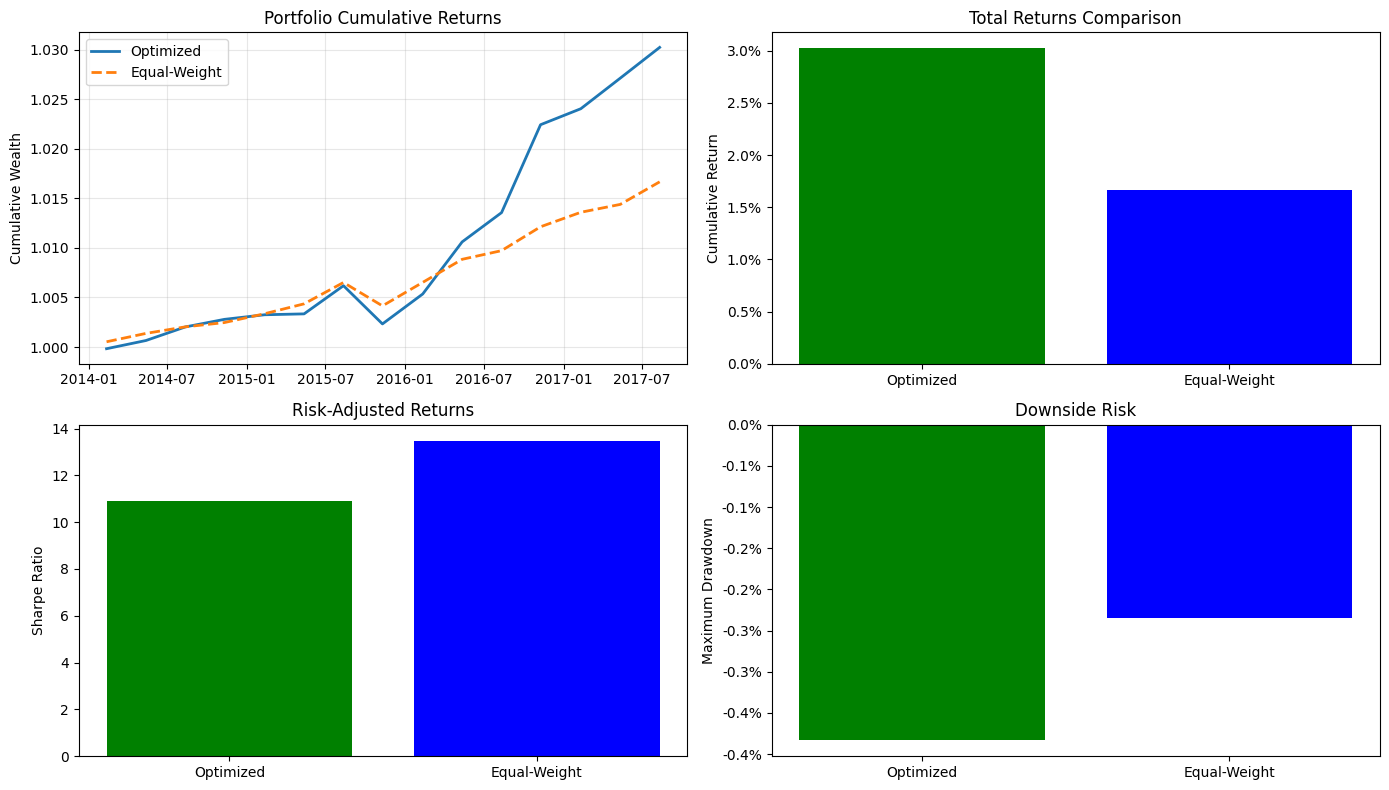

In [7]:
# Backtest visualization
opt_cumulative = (1 + opt_returns_series).cumprod()
eq_cumulative = (1 + equal_returns_series).cumprod()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Cumulative returns
axes[0, 0].plot(opt_cumulative.index, opt_cumulative.values, label='Optimized', linewidth=2)
axes[0, 0].plot(eq_cumulative.index, eq_cumulative.values, label='Equal-Weight', linewidth=2, linestyle='--')
axes[0, 0].set_ylabel('Cumulative Wealth')
axes[0, 0].set_title('Portfolio Cumulative Returns')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Total returns
axes[0, 1].bar(['Optimized', 'Equal-Weight'], [opt_cum_ret, eq_cum_ret], color=['green', 'blue'])
axes[0, 1].set_ylabel('Cumulative Return')
axes[0, 1].set_title('Total Returns Comparison')
axes[0, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

# Sharpe ratio
axes[1, 0].bar(['Optimized', 'Equal-Weight'], [opt_sharpe, eq_sharpe], color=['green', 'blue'])
axes[1, 0].set_ylabel('Sharpe Ratio')
axes[1, 0].set_title('Risk-Adjusted Returns')

# Max drawdown
axes[1, 1].bar(['Optimized', 'Equal-Weight'], [opt_max_dd, eq_max_dd], color=['green', 'blue'])
axes[1, 1].set_ylabel('Maximum Drawdown')
axes[1, 1].set_title('Downside Risk')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))

plt.tight_layout()
plt.show()

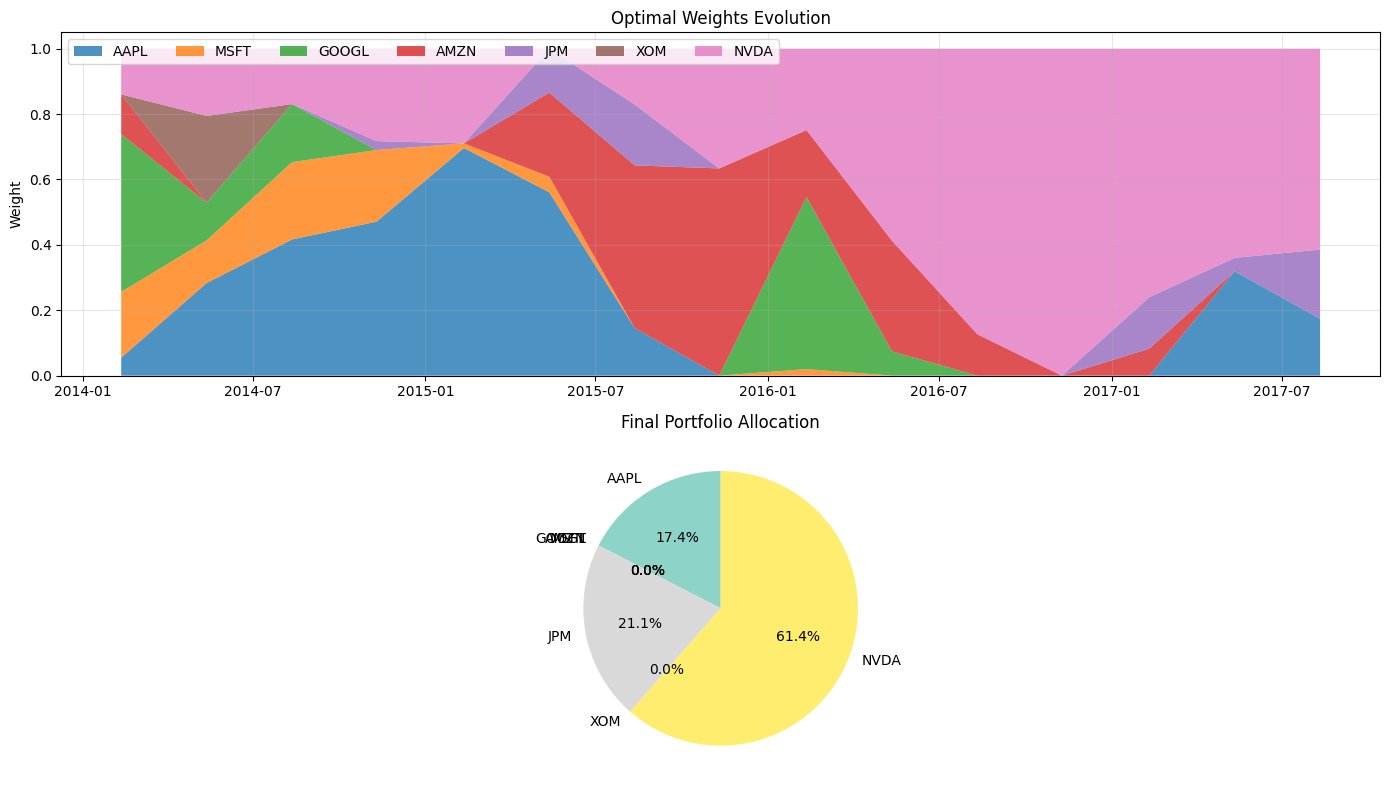


Final Optimal Allocation:
----------------------------------------
AAPL         17.42%
MSFT          0.00%
GOOGL         0.00%
AMZN          0.00%
JPM          21.14%
XOM           0.00%
NVDA         61.44%


In [8]:
# Portfolio weights evolution
weights_df = pd.DataFrame(optimized_weights_history, columns=stocks, index=dates_history)
final_weights = optimized_weights_history[-1] if optimized_weights_history else np.array([1/len(stocks)]*len(stocks))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Stacked area
axes[0].stackplot(weights_df.index, [weights_df[stock].values for stock in stocks], 
                   labels=stocks, alpha=0.8)
axes[0].set_ylabel('Weight')
axes[0].set_title('Optimal Weights Evolution')
axes[0].legend(loc='upper left', ncol=7)
axes[0].grid(True, alpha=0.3)

# Final allocation pie
colors = plt.cm.Set3(np.linspace(0, 1, len(stocks)))
axes[1].pie(final_weights, labels=stocks, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Final Portfolio Allocation')

plt.tight_layout()
plt.show()

print("\nFinal Optimal Allocation:")
print("-"*40)
for stock, weight in zip(stocks, final_weights):
    print(f"{stock:<10} {weight:>8.2%}")

In [9]:
# Sensitivity analysis - risk-free rate impact
risk_free_rates = np.array([0.01, 0.02, 0.03, 0.04, 0.05]) / 252
results_sensitivity = []

train_data = backtest_data.iloc[-252:].copy()
recent_mean_returns = train_data.mean()

for rf_rate in risk_free_rates:
    def neg_sharpe_sens(weights, mean_ret, cov_mat, rf):
        portfolio_return = np.sum(mean_ret * weights)
        portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
        sharpe_ratio = (portfolio_return - rf) / portfolio_std if portfolio_std > 0 else 0
        return -sharpe_ratio
    
    result = minimize(neg_sharpe_sens, init_guess,
                     args=(recent_mean_returns, train_data.cov(), rf_rate),
                     method='SLSQP', bounds=bounds, constraints=constraints)
    
    opt_w = result.x
    port_ret = np.sum(recent_mean_returns * opt_w)
    port_std = np.sqrt(np.dot(opt_w.T, np.dot(train_data.cov(), opt_w)))
    sharpe = (port_ret - rf_rate) / port_std if port_std > 0 else 0
    
    results_sensitivity.append({
        'rf_rate': rf_rate * 252 * 100,
        'sharpe': sharpe,
        'return': port_ret * 252 * 100,
        'std': port_std * np.sqrt(252) * 100
    })

sensitivity_df = pd.DataFrame(results_sensitivity)
print("\nSensitivity to Risk-Free Rate:")
print("-"*60)
print(sensitivity_df.to_string(index=False))


Sensitivity to Risk-Free Rate:
------------------------------------------------------------
 rf_rate   sharpe    return       std
     1.0 0.190334 47.315757 15.328930
     2.0 0.186239 47.639270 15.437186
     3.0 0.182169 47.920419 15.533488
     4.0 0.178125 48.215258 15.636781
     5.0 0.174109 48.524684 15.747571


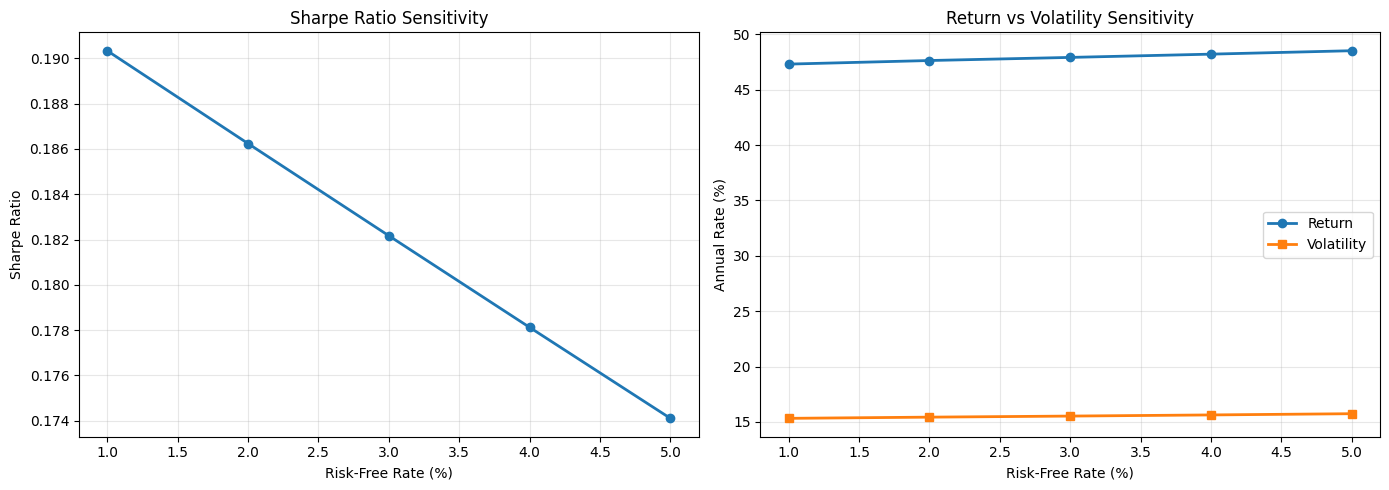

In [10]:
# Sensitivity visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(sensitivity_df['rf_rate'], sensitivity_df['sharpe'], marker='o', linewidth=2)
axes[0].set_xlabel('Risk-Free Rate (%)')
axes[0].set_ylabel('Sharpe Ratio')
axes[0].set_title('Sharpe Ratio Sensitivity')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sensitivity_df['rf_rate'], sensitivity_df['return'], marker='o', label='Return', linewidth=2)
axes[1].plot(sensitivity_df['rf_rate'], sensitivity_df['std'], marker='s', label='Volatility', linewidth=2)
axes[1].set_xlabel('Risk-Free Rate (%)')
axes[1].set_ylabel('Annual Rate (%)')
axes[1].set_title('Return vs Volatility Sensitivity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Constraint testing
constraints_list = [
    ('Unconstrained', tuple((0, 1) for _ in range(len(stocks)))),
    ('Max 30%', tuple((0, 0.3) for _ in range(len(stocks)))),
    ('Max 20%', tuple((0, 0.2) for _ in range(len(stocks)))),
    ('Min 5%', tuple((0.05, 1) for _ in range(len(stocks))))
]

constraint_results = []
for constraint_name, bounds_c in constraints_list:
    result_c = minimize(neg_sharpe, init_guess,
                       args=(recent_mean_returns, train_data.cov()),
                       method='SLSQP', bounds=bounds_c, constraints=constraints)
    
    opt_w_c = result_c.x
    port_ret = np.sum(recent_mean_returns * opt_w_c) * 252
    port_std = np.sqrt(np.dot(opt_w_c.T, np.dot(train_data.cov(), opt_w_c))) * np.sqrt(252)
    sharpe = (port_ret - 0.02) / port_std if port_std > 0 else 0
    
    constraint_results.append({
        'Constraint': constraint_name,
        'Return': port_ret,
        'Volatility': port_std,
        'Sharpe': sharpe
    })

constraint_df = pd.DataFrame(constraint_results)
print("\nConstraint Impact Analysis:")
print("="*60)
print(constraint_df.to_string(index=False))


Constraint Impact Analysis:
   Constraint   Return  Volatility   Sharpe
Unconstrained 0.476393    0.154372 2.956450
      Max 30% 0.439225    0.147124 2.849467
      Max 20% 0.427844    0.159634 2.554867
       Min 5% 0.427360    0.145739 2.795129


In [12]:
print("\n✓ Backtesting & Advanced Analysis Complete")


✓ Backtesting & Advanced Analysis Complete


In [ ]:
# Save backtesting results for app.ipynb
import json
import pickle

# Save metrics
metrics = {
    'opt_cum_ret': float(opt_cum_ret),
    'opt_sharpe': float(opt_sharpe),
    'opt_max_dd': float(opt_max_dd),
    'eq_cum_ret': float(eq_cum_ret),
    'eq_sharpe': float(eq_sharpe),
    'eq_max_dd': float(eq_max_dd),
    'num_periods': len(dates_history)
}
with open('backtest_metrics.json', 'w') as f:
    json.dump(metrics, f)

# Save arrays
np.save('optimized_returns.npy', np.array(optimized_returns))
np.save('equal_weight_returns.npy', np.array(equal_weight_returns))
np.save('final_weights.npy', np.array(final_weights))

# Save dates
dates_str = [str(d) for d in dates_history]
with open('dates_history.json', 'w') as f:
    json.dump(dates_str, f)

# Save Series as CSV
opt_returns_series.to_csv('opt_returns_series.csv')
equal_returns_series.to_csv('equal_returns_series.csv')
weights_df.to_csv('weights_evolution.csv')

print("✓ Backtesting results saved for app.ipynb")